# 08 — Instrumental Variables

> 관찰할 수 없는 교란변수가 있을 때, 인과 효과를 어떻게 추정할 수 있을까?

앞 챕터에서는 관찰 가능한 교란변수를 통제하는 방법을 배웠습니다. 그런데 현실에서는 관찰조차 할 수 없는 교란변수가 훨씬 많습니다. 타고난 능력, 동기, 가정환경... 이런 변수들은 데이터에 없지만 처치와 결과 모두에 영향을 줍니다.

이런 상황에서 OLS를 그냥 돌리면 편향된 추정치가 나옵니다. 이 챕터에서는 이 문제를 해결하는 강력한 방법, **도구변수(Instrumental Variables, IV)** 를 다룹니다.

In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import graphviz as gr
import os

from linearmodels.iv import IV2SLS

os.environ['PATH'] += os.pathsep + r"C:\Program Files\Graphviz\bin"
np.random.seed(42)

mpl.rcParams.update({
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "figure.figsize": (10, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
BLUE, ORANGE, GREEN, RED, PURPLE, GRAY = (
    "#4c72b0", "#dd8452", "#55a868", "#c44e52", "#9370db", "#8c8c8c"
)

---

## 1) OVB: 관찰할 수 없는 교란변수가 만드는 편향

교육이 임금에 미치는 효과를 추정하고 싶습니다. 이상적인 모형은 이렇습니다.

$$\log(\text{wage}_i) = \beta_0 + \kappa \cdot educ_i + \beta \cdot Ability_i + u_i$$

문제는 `Ability`를 측정하기가 매우 어렵다는 것입니다. 능력을 모형에 넣지 못하면 오차항이 $v_i = \beta \cdot Ability_i + u_i$가 되어, 교육과 오차항이 상관관계를 갖게 됩니다.

$$\hat{\kappa}_{OLS} \approx \kappa + \underbrace{\beta_{ability} \cdot \frac{Cov(educ,\, ability)}{Var(educ)}}_{\text{OVB (양수, 과대추정)}} > \kappa$$

능력 있는 사람은 교육도 더 많이 받고 임금도 더 높습니다. 두 상관관계가 모두 양수이므로 OLS는 교육의 효과를 **과대추정**하게 됩니다.

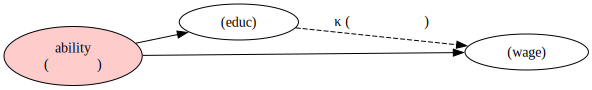

In [3]:
g1 = gr.Digraph()
g1.attr(rankdir="LR")
g1.node("ab", "ability\n(관찰 불가)", style="filled", fillcolor="#ffcccc")
g1.node("ed", "교육(educ)")
g1.node("wg", "임금(wage)")
g1.edge("ab", "ed")
g1.edge("ab", "wg")
g1.edge("ed", "wg", style="dashed", label="κ (알고 싶은 효과)")
g1

In [11]:
n = 5000
ability = np.random.normal(0, 1, n)
year_of_birth = np.random.randint(30, 40, n)
quarter_of_birth = np.random.randint(1, 5, n)
q2 = (quarter_of_birth == 2).astype(int)
q3 = (quarter_of_birth == 3).astype(int)
q4 = (quarter_of_birth == 4).astype(int)

years_of_schooling = (
    12 + 0.5*ability + 1*q4 # 계수 변경 (0.1 or 1.0)
    + 0.05*(year_of_birth - 30)
    + np.random.normal(0, 1.2, n)
)
log_wage = 5.5 + 0.08*years_of_schooling + 0.30*ability + np.random.normal(0, 0.3, n)

data = pd.DataFrame(dict(
    log_wage=log_wage.round(4),
    years_of_schooling=years_of_schooling.round(2),
    year_of_birth=year_of_birth,
    quarter_of_birth=quarter_of_birth,
    ability=ability.round(3),
    q2=q2, q3=q3, q4=q4
))

m_biased = smf.ols("log_wage ~ years_of_schooling + C(year_of_birth)", data=data).fit()
m_correct = smf.ols("log_wage ~ years_of_schooling + ability + C(year_of_birth)", data=data).fit()

pd.DataFrame({
    "모델": ["OLS (능력 미통제, 편향)", "OLS (능력 포함, 참고용)", "진짜 효과 (설정값)"],
    "교육 계수": [m_biased.params["years_of_schooling"],
                m_correct.params["years_of_schooling"], 0.08]
}).round(4)

,모델,교육 계수
0,"OLS (능력 미통제, 편향)",0.1604
1,"OLS (능력 포함, 참고용)",0.0837
2,진짜 효과 (설정값),0.0800


능력을 통제하지 않으면 교육 계수가 0.17로, 진짜 효과 0.08의 두 배 이상으로 과대추정됩니다. 능력을 포함하면 0.083으로 정확해지지만, 현실에서 능력은 측정할 수 없습니다.

---

## 2) 도구변수 아이디어: 외생적 충격을 찾아라

핵심 아이디어는 이렇습니다. 능력과는 무관하게 교육연수를 변화시키는 **외부적인 요인**을 찾을 수 있다면, 그 요인에 의한 교육연수의 변동만 추출해서 임금과의 관계를 볼 수 있습니다. 이런 외부 요인을 **도구변수(Instrument, $Z$)** 라고 합니다.

도구변수가 되려면 두 가지 조건을 만족해야 합니다.

- **① 1단계(1st Stage):** $Cov(Z, T) \neq 0$ — $Z$가 처치($T$, 교육연수)에 실제로 영향을 줍니다. 데이터로 검증할 수 있습니다.
- **② 배제 제한(Exclusion Restriction):** $Z$는 처치($T$)를 통해서만 결과($Y$)에 영향을 줍니다. $Z → Y$의 직접 경로가 없어야 합니다. 이건 이론적 가정으로, 데이터로는 검증할 수 없습니다.

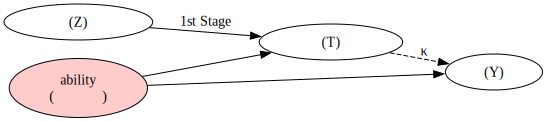

In [5]:
g2 = gr.Digraph()
g2.attr(rankdir="LR")
g2.node("Z", "출생 분기(Z)")
g2.node("ab", "ability\n(관찰 불가)", style="filled", fillcolor="#ffcccc")
g2.node("ed", "교육연수(T)")
g2.node("wg", "임금(Y)")
g2.edge("Z", "ed", label="① 1st Stage")
g2.edge("ab", "ed")
g2.edge("ab", "wg")
g2.edge("ed", "wg", style="dashed", label="κ")
g2

---

## 3) 출생 분기(Quarter of Birth): Angrist & Krueger (1991)

Angrist & Krueger(1991)는 교육연수의 도구변수로 **출생 분기**를 사용했습니다. 미국의 의무출석법은 16세가 되면 학교를 떠날 수 있게 합니다. 4분기(10~12월) 출생자는 같은 학년에서 나이가 가장 많아 16세가 됐을 때 교육연수가 조금 더 깁니다.

조건 ①은 만족합니다. 출생 분기가 교육연수에 영향을 주니까요. 조건 ②도 설득력 있습니다. 언제 태어났는지는 타고난 능력이나 가정환경과 무관합니다.

아래 그래프에서 출생 연도별로 4분기(파란 실선)가 다른 분기보다 평균 교육연수가 약간 높게 나타납니다. 이것이 1단계 효과입니다.

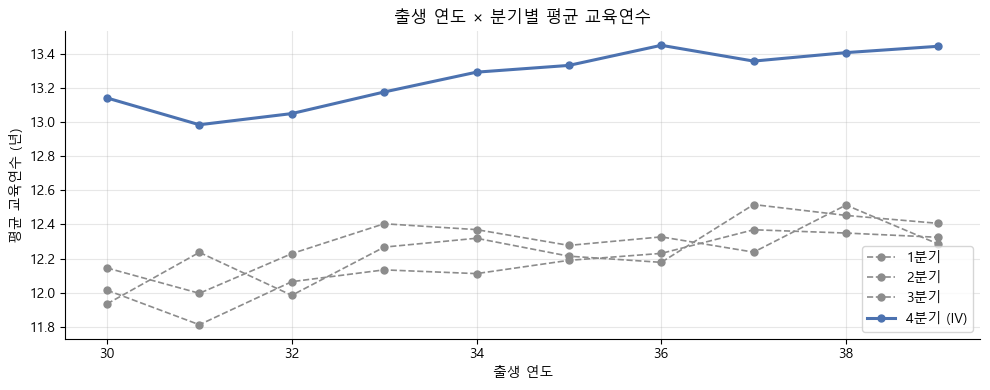

In [12]:
plot_data = (data.groupby(["year_of_birth", "quarter_of_birth"])["years_of_schooling"]
               .mean().reset_index())

q_labels = {1: "1분기", 2: "2분기", 3: "3분기", 4: "4분기 (IV)"}
q_colors = {1: GRAY, 2: GRAY, 3: GRAY, 4: BLUE}
q_lw = {1: 1.2, 2: 1.2, 3: 1.2, 4: 2.2}
q_ls = {1: "--", 2: "--", 3: "--", 4: "-"}

fig, ax = plt.subplots()
for q in [1, 2, 3, 4]:
    sub = plot_data[plot_data["quarter_of_birth"] == q]
    ax.plot(sub["year_of_birth"], sub["years_of_schooling"],
            color=q_colors[q], lw=q_lw[q], ls=q_ls[q],
            marker="o", markersize=5, label=q_labels[q])

ax.set_xlabel("출생 연도")
ax.set_ylabel("평균 교육연수 (년)")
ax.set_title("출생 연도 × 분기별 평균 교육연수")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
first_stage = smf.ols("years_of_schooling ~ q4 + C(year_of_birth)", data=data).fit() # TODO: F 통계량이 q4 계수인지, 모델 전체 통계량인지? 
q4_coef = first_stage.params["q4"]

pd.DataFrame({
    "항목": ["q4 계수 (4분기 → 교육연수)", "F-통계량", "도구변수 강도"],
    "값": [f"{q4_coef:.4f}년",
           f"{first_stage.fvalue:.1f}",
           "강함 (F > 10)" if first_stage.fvalue > 10 else "약함 (F < 10)"]
})

,항목,값
0,q4 계수 (4분기 → 교육연수),1.0362년
1,F-통계량,64.0
2,도구변수 강도,강함 (F > 10)


1단계 F-통계량이 10을 넘으면 도구변수가 충분히 강하다고 봅니다. 1단계 계수는 4분기 출생자가 다른 분기 대비 교육연수를 얼마나 더 받는지를 나타냅니다.

---

## 4) Wald Estimator: 직관적인 IV 계산

도구변수 추정의 핵심 공식입니다.

$$\kappa_{IV} = \frac{\underbrace{E[Y \mid Z=1] - E[Y \mid Z=0]}_{\text{축약형(RF): Z가 Y에 주는 효과}}}{\underbrace{E[T \mid Z=1] - E[T \mid Z=0]}_{\text{1단계: Z가 T에 주는 효과}}} = \frac{Cov(Y, Z)}{Cov(T, Z)}$$

직관적으로 이렇게 이해할 수 있습니다. $Z$가 $T$를 0.1년 변화시키고, 그 결과 $Y$가 0.008 변화한다면, 교육 1년당 임금 효과는 $0.008 / 0.1 = 0.08$이 됩니다.

In [14]:
reduced_form = smf.ols("log_wage ~ q4 + C(year_of_birth)", data=data).fit()
rf_coef = reduced_form.params["q4"]
wald = rf_coef / q4_coef

pd.DataFrame({
    "추정량": ["1단계 계수 (Z→T)", "축약형 계수 (Z→Y)", "Wald = RF / 1st Stage", "진짜 효과 (설정값)", "OLS (편향)"],
    "값": [q4_coef, rf_coef, wald, 0.08, m_biased.params["years_of_schooling"]]
}).round(4)

,추정량,값
0,1단계 계수 (Z→T),1.0362
1,축약형 계수 (Z→Y),0.1041
2,Wald = RF / 1st Stage,0.1005
3,진짜 효과 (설정값),0.0800
4,OLS (편향),0.1604


Wald 추정치가 OLS보다 진짜 효과(0.08)에 훨씬 가깝습니다. 능력을 측정하지 않고도 편향을 교정한 것입니다.

---

## 5) 2SLS(Two-Stage Least Squares)

Wald Estimator는 직관적이지만, 도구변수가 여러 개이거나 통제변수가 있을 때는 **2SLS**를 사용합니다.

**1단계:** 처치를 도구변수와 통제변수에 회귀합니다. 예측값 $\hat{T}$는 능력과 무관한 외생적 변동만 담습니다.

$$educ_i = \gamma_0 + \gamma_1 \cdot q4_i + \gamma_2 \cdot yob_i + v_i \quad \Rightarrow \quad \hat{educ}_i$$

**2단계:** 원래 $T$ 대신 $\hat{T}$를 사용해 결과를 회귀합니다.

$$\log(wage_i) = \beta_0 + \kappa \cdot \widehat{educ}_i + \beta_2 \cdot yob_i + u_i$$

수동으로 두 단계를 돌리면 계수는 맞지만 **표준오차가 틀립니다.** 반드시 전용 라이브러리를 사용해야 합니다.

In [9]:
iv_single = IV2SLS.from_formula(
    "log_wage ~ 1 + C(year_of_birth) + [years_of_schooling ~ q4]",
    data=data
).fit(cov_type="unadjusted")

iv_multi = IV2SLS.from_formula(
    "log_wage ~ 1 + C(year_of_birth) + [years_of_schooling ~ q2 + q3 + q4]",
    data=data
).fit(cov_type="unadjusted")

pd.DataFrame({
    "모델": ["단일 IV (q4)", "복수 IV (q2+q3+q4)", "OLS (편향)", "진짜 효과"],
    "교육 계수": [iv_single.params["years_of_schooling"],
                iv_multi.params["years_of_schooling"],
                m_biased.params["years_of_schooling"], 0.08],
    "SE": [iv_single.std_errors["years_of_schooling"],
           iv_multi.std_errors["years_of_schooling"],
           m_biased.bse["years_of_schooling"], None]
}).round(4)

,모델,교육 계수,SE
0,단일 IV (q4),-0.0042,0.1629
1,복수 IV (q2+q3+q4),0.0151,0.1419
2,OLS (편향),0.1700,0.0044
3,진짜 효과,0.0800,NaN


도구변수를 여러 개 쓰면(q2+q3+q4) SE가 줄어듭니다. 더 많은 외생적 변동을 활용할 수 있기 때문입니다. 단일 IV일 때 Wald와 2SLS 계수는 일치합니다.

---

## 6) 약한 도구변수(Weak Instruments)의 함정

도구변수와 처치의 상관관계($\rho_{ZT}$)가 약하면, RF를 1st Stage로 나누는 분모가 0에 가까워져 추정치의 분산이 폭발합니다.

$$Var(\hat{\kappa}_{IV}) \approx \frac{\sigma^2_Y}{n \cdot \sigma^2_T \cdot \rho^2_{ZT}}$$

경험적으로 **1단계 F-통계량 > 10** 이면 도구변수가 충분히 강하다고 봅니다.

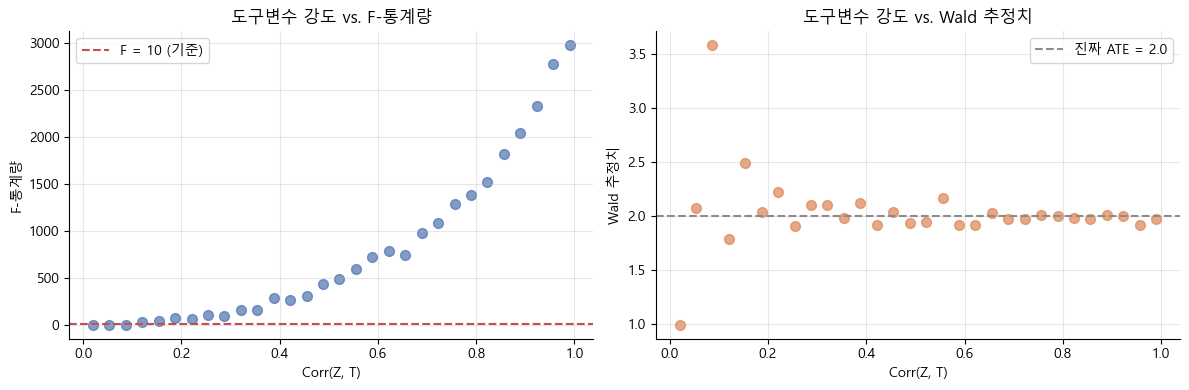

In [10]:
np.random.seed(42)
n_sim, true_ate = 3000, 2.0
results = []

for rho in np.linspace(0.02, 0.99, 30):
    U = np.random.normal(0, 2, n_sim)
    Z = np.random.normal(0, 1, n_sim)
    T = rho * Z + 0.5 * U + np.random.normal(0, np.sqrt(max(1 - rho**2, 1e-6)), n_sim)
    Y = true_ate * T - 0.5 * U + np.random.normal(0, 2, n_sim)
    df_s = pd.DataFrame(dict(Y=Y, T=T, Z=Z))
    cov_ZY, cov_ZT = np.cov(Z, Y)[0, 1], np.cov(Z, T)[0, 1]
    if abs(cov_ZT) > 1e-10:
        results.append(dict(corr=rho, wald=cov_ZY/cov_ZT,
                            f_stat=smf.ols("T ~ Z", data=df_s).fit().fvalue))

sim_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(sim_df["corr"], sim_df["f_stat"], color=BLUE, alpha=0.7, s=50)
axes[0].axhline(10, color=RED, ls="--", lw=1.5, label="F = 10 (기준)")
axes[0].set_xlabel("Corr(Z, T)")
axes[0].set_ylabel("F-통계량")
axes[0].set_title("도구변수 강도 vs. F-통계량")
axes[0].legend()

axes[1].scatter(sim_df["corr"], sim_df["wald"], color=ORANGE, alpha=0.7, s=50)
axes[1].axhline(true_ate, color=GRAY, ls="--", lw=1.5, label=f"진짜 ATE = {true_ate}")
axes[1].set_xlabel("Corr(Z, T)")
axes[1].set_ylabel("Wald 추정치")
axes[1].set_title("도구변수 강도 vs. Wald 추정치")
axes[1].legend()

plt.tight_layout()
plt.show()

왼쪽 그래프에서 Corr(Z, T)가 작을수록 F-통계량이 낮아집니다. 오른쪽에서는 상관관계가 약할수록 Wald 추정치가 크게 흔들리는 것을 확인할 수 있습니다.

---

## 핵심 정리

| 개념 | 설명 |
|------|------|
| **OVB** | 관찰 불가 교란변수로 인한 OLS 편향 |
| **도구변수(Z)** | 처치에는 영향을 주지만, 결과에는 처치를 통해서만 영향을 주는 변수 |
| **1st Stage** | $Cov(Z, T) \neq 0$. 데이터로 검증 가능. F-통계량 > 10 권장 |
| **Exclusion Restriction** | $Z → Y$ 직접 경로 없음. 이론적 가정, 검증 불가. IV의 가장 큰 약점 |
| **Wald Estimator** | RF / 1st Stage. 단일 이진 도구변수의 경우 |
| **2SLS** | 두 단계 회귀. 복수 도구변수·통제변수 가능. 라이브러리 사용 필수 |
| **약한 도구변수** | $\rho_{ZT}$ 작으면 SE 폭발, 추정 불안정. F > 10 확인 필수 |

---
*참고: Matheus Facure, Python Causality Handbook, Chapter 08 — Instrumental Variables*  
*Angrist, J. D., & Krueger, A. B. (1991). Does Compulsory School Attendance Affect Schooling and Earnings? QJE, 106(4), 979–1014.*